<a href="https://colab.research.google.com/github/JenilGoti/Human_Action_Detaction/blob/main/Human_Action_Detaction_Transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Human Action Detaction
dataset:- emirhanai/human-action-detection-artificial-intelligence

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from torchvision.transforms import v2
import torch

transform_train = v2.Compose([
    v2.Resize((224,224)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = v2.Compose([
    v2.Resize((224,224)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
!pwd

/content


In [ ]:
from torchvision import datasets

train_dir = "/kaggle/input/human-action-detection-artificial-intelligence/emirhan_human_dataset/datasets/human_data/train_data"
test_dir = "/kaggle/input/human-action-detection-artificial-intelligence/emirhan_human_dataset/datasets/human_data/test_data"

train_data = datasets.ImageFolder(root=train_dir, transform=transform_train, target_transform=None)
test_data = datasets.ImageFolder(root=test_dir, transform=transform_test, target_transform=None)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 15000
     Root location: /kaggle/input/human-action-detection-artificial-intelligence/emirhan_human_dataset/datasets/human_data/train_data
     StandardTransform
 Transform: Compose(
                  Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
                  RandomHorizontalFlip(p=0.5)
                  ToImage()
                  ToDtype(scale=True)
                  Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
            ),
 Dataset ImageFolder
     Number of datapoints: 3000
     Root location: /kaggle/input/human-action-detection-artificial-intelligence/emirhan_human_dataset/datasets/human_data/test_data
     StandardTransform
 Transform: Compose(
                  Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
                  ToImage()
                  ToDtype(scale=True)
                  Normalize(mean=[0.485, 0.456,

In [ ]:
from torch.utils.data import DataLoader
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [ ]:
from torchvision import models
model = models.resnet18(weights="IMAGENET1K_V1")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 194MB/s]


In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary

summary(model, input_size=(32, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [32, 1000]                --
├─Conv2d: 1-1                            [32, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        128
├─ReLU: 1-3                              [32, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [32, 64, 56, 56]          --
├─Sequential: 1-5                        [32, 64, 56, 56]          --
│    └─BasicBlock: 2-1                   [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-1                  [32, 64, 56, 56]          36,864
│    │    └─BatchNorm2d: 3-2             [32, 64, 56, 56]          128
│    │    └─ReLU: 3-3                    [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-4                  [32, 64, 56, 56]          36,864
│    │    └─BatchNorm2d: 3-5             [32, 64, 56, 56]          128
│    │    └─ReLU: 3-6                    [32, 64, 56, 56]          --
│

In [ ]:
len(train_data.classes)

15

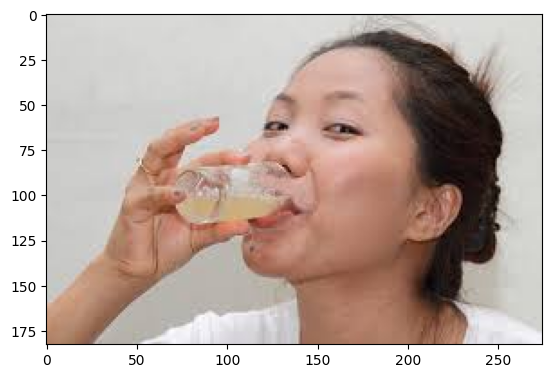

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("/kaggle/input/human-action-detection-artificial-intelligence/emirhan_human_dataset/datasets/human_data/test_data/drinking/images_064 (2).jpg")
imgplot = plt.imshow(img)
plt.show()

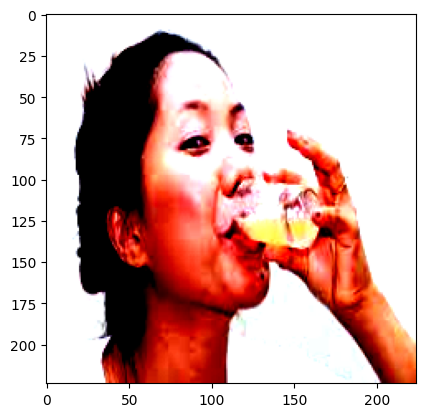

In [ ]:
img = Image.open("/kaggle/input/human-action-detection-artificial-intelligence/emirhan_human_dataset/datasets/human_data/test_data/drinking/images_064 (2).jpg")
img = transform_train(img)
img = img.permute(1,2,0 )
plt.imshow(img)

In [ ]:
from torch import nn
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(train_data.classes))
model = model.to(device)

In [ ]:
img = Image.open("/kaggle/input/human-action-detection-artificial-intelligence/emirhan_human_dataset/datasets/human_data/train_data/calling/images_083.jpg")
img = transform_train(img)
img = img.to(device)

model.eval()
with torch.inference_mode():
  y_preds = model(img.unsqueeze(dim=0))
  y_preds = torch.softmax(y_preds, dim=1)
  y_preds = torch.argmax(y_preds, dim=1)

print(y_preds)

tensor([1], device='cuda:0')


In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=2)

In [ ]:
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

In [ ]:
def train_model(model, train_loader, loss_fn, optimizer):
  model.train()
  running_loss = 0
  acc = 0

  for batch, (X,y) in enumerate(train_loader):
    X, y = X.to(device), y.to(device)
    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    running_loss += loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    acc += accuracy_fn(y, y_pred.argmax(dim=1))

  acc /= len(train_loader)
  running_loss /= len(train_loader)
  return running_loss, acc

In [ ]:
def test_model(model, loss_fn, test_loader, scheduler):
  model.eval()
  test_loss = 0
  test_acc = 0

  with torch.inference_mode():
    for batch, (X,y) in enumerate(test_loader):
      X, y = X.to(device), y.to(device)
      y_pred = model(X)
      loss = loss_fn(y_pred, y)
      test_loss += loss.item()
      test_acc += accuracy_fn(y_pred=y_pred.argmax(dim=1), y_true=y)

    test_acc /= len(test_loader)
    test_loss /= len(test_loader)
    scheduler.step(test_loss)

  return test_loss, test_acc

In [ ]:
import time

epochs = 10
start = time.time()
for epoch in range(epochs):
  train_loss, train_acc = train_model(model=model, loss_fn=loss_fn, optimizer=optimizer, train_loader=train_loader)
  test_loss, test_acc = test_model(model=model, loss_fn=loss_fn, test_loader=test_loader, scheduler=scheduler)
  print(f"Epoch: {epoch} | Train loss: {train_loss} | Train acc {train_acc} | Test loss {test_loss} | Test acc {test_acc}")
end = time.time()
print(f"Time taken: {end-start}")

Epoch: 0 | Train loss: 1.0817008687616156 | Train acc 66.69331911869226 | Test loss 0.86868715080175 | Test acc 72.59530141843972
Epoch: 1 | Train loss: 0.5559429467550473 | Train acc 82.6114960909737 | Test loss 0.7934591865285914 | Test acc 75.0997340425532
Epoch: 2 | Train loss: 0.3336592218610269 | Train acc 90.10083511016346 | Test loss 0.8294162984858168 | Test acc 75.19946808510639
Epoch: 3 | Train loss: 0.2103519833910821 | Train acc 94.08093461265103 | Test loss 0.8020023912032868 | Test acc 75.96409574468085
Epoch: 4 | Train loss: 0.12540679322535803 | Train acc 96.6706645344705 | Test loss 0.8631493027539964 | Test acc 75.0997340425532
Epoch: 5 | Train loss: 0.06540580988645173 | Train acc 98.48525230987919 | Test loss 0.7662245925674414 | Test acc 77.33820921985816
Epoch: 6 | Train loss: 0.04512321783789694 | Train acc 99.21375266524521 | Test loss 0.7589247071164402 | Test acc 77.73714539007092
Epoch: 7 | Train loss: 0.03564123343477752 | Train acc 99.45362473347548 | Test

In [ ]:
img = Image.open("/kaggle/input/human-action-detection-artificial-intelligence/emirhan_human_dataset/datasets/human_data/test_data/laughing/images_035 (2).jpg")

model.eval()
img = transform_test(img)
img = img.to(device)

with torch.inference_mode():
  y_preds = model(img.unsqueeze(dim=0))
  y_preds = torch.softmax(y_preds, dim=1)
  y_preds = torch.argmax(y_preds, dim=1)

y_preds.item()
class_names = train_data.classes
class_names[y_preds.item()]

'laughing'

In [ ]:
%%capture
!pip install torchmetrics

In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
import numpy as np

def make_confusion_matrix(model, test_loader):
  model.eval()
  y_true = []
  y_pred= []

  with torch.inference_mode():
    for inputs, labels in test_loader:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)
      #_, predicted = torch.max(outputs, 1)
      test_preds = torch.softmax(outputs.squeeze(), dim=1).argmax(dim=1)
      y_true.append(labels.cpu().numpy())
      y_pred.append(test_preds.cpu().numpy())

  y_pred = np.concatenate(y_pred)
  y_pred = torch.tensor(y_pred)

  test_data.targets = torch.tensor(test_data.targets)

  confmat = ConfusionMatrix(num_classes=len(class_names), task="multiclass")
  confmat_tensor = confmat(preds = y_pred, target=test_data.targets)

  fig, ax = plot_confusion_matrix(
      conf_mat = confmat_tensor.numpy(),
      class_names = class_names,
      figsize=(10,10)

  )

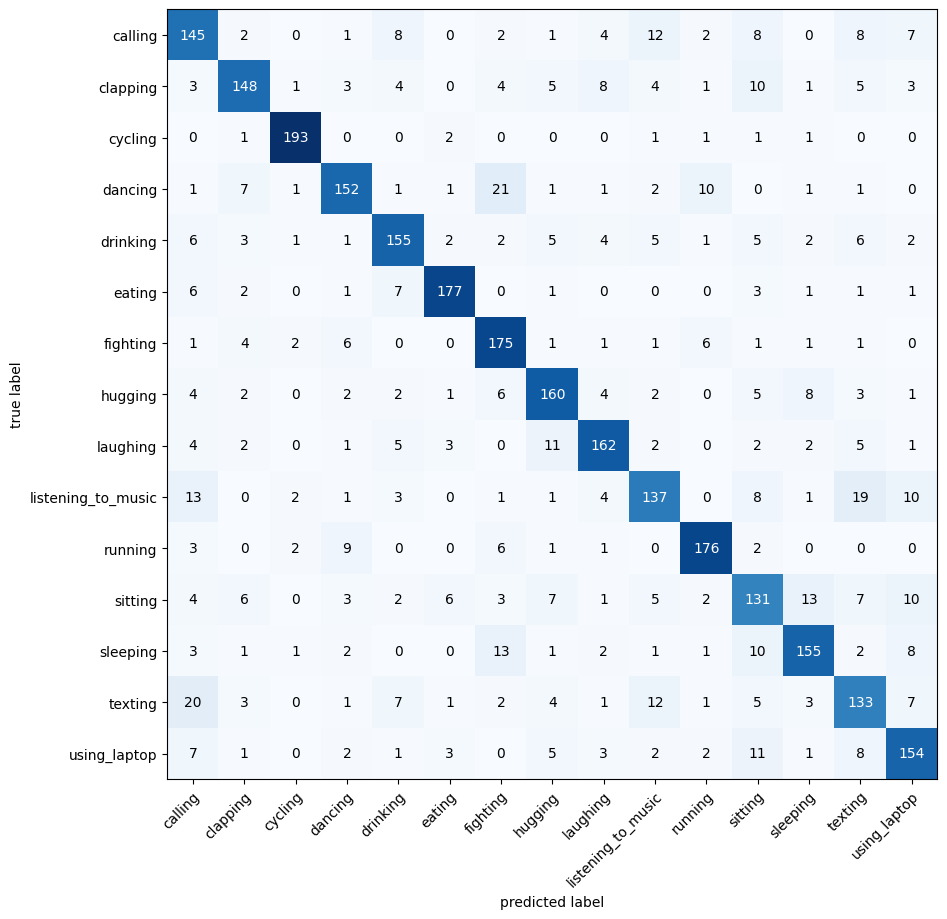

In [ ]:
make_confusion_matrix(model, test_loader)

## Freezing parameters

In [ ]:
from torchvision import models
model_2 = models.resnet18(weights="IMAGENET1K_V1")

for param in model_2.parameters():
  param.requires_grad = False

num_ftrs  = model_2.fc.in_features
model_2.fc = nn.Linear(num_ftrs, len(train_data.classes))

model_2.to(device)

optimizer = torch.optim.Adam(model_2.fc.parameters(), lr=1e-4)
loss_fn = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=2)

In [ ]:
import time

epochs = 10
start= time.time()
for epoch in range(10):
  train_loss, train_acc = train_model(model=model_2, loss_fn=loss_fn, optimizer=optimizer, train_loader=train_loader)
  test_loss, test_acc = test_model(model=model_2, loss_fn=loss_fn, test_loader=test_loader, scheduler=scheduler)
  print(f"Epoch: {epoch} | Train loss: {train_loss} | Train acc: {train_acc} | test loss: {test_loss} | test acc: {test_acc}")

end = time.time()
print(f"Time taken : {end-start}")

Epoch: 0 | Train loss: 2.3507471915755445 | Train acc: 28.00506396588486 | test loss: 2.061869702440627 | test acc: 41.00177304964539
Epoch: 1 | Train loss: 1.834457329087166 | Train acc: 49.04495380241649 | test loss: 1.7462642605000354 | test acc: 49.33510638297872
Epoch: 2 | Train loss: 1.599132843109082 | Train acc: 54.81076759061834 | test loss: 1.588296485391069 | test acc: 53.224734042553195
Epoch: 3 | Train loss: 1.4631415780927581 | Train acc: 57.33164534470505 | test loss: 1.4923832584568795 | test acc: 55.37455673758865
Epoch: 4 | Train loss: 1.381458028038936 | Train acc: 59.13068585643213 | test loss: 1.43916070239341 | test acc: 55.89539007092199
Epoch: 5 | Train loss: 1.3151811126198596 | Train acc: 60.29228855721393 | test loss: 1.3776032826367846 | test acc: 57.62411347517731
Epoch: 6 | Train loss: 1.2766503179505435 | Train acc: 61.23622956645345 | test loss: 1.3383325796495094 | test acc: 58.65469858156029
Epoch: 7 | Train loss: 1.2403730732291491 | Train acc: 61.880

/tmp/ipykernel_557/1065802089.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_data.targets = torch.tensor(test_data.targets)


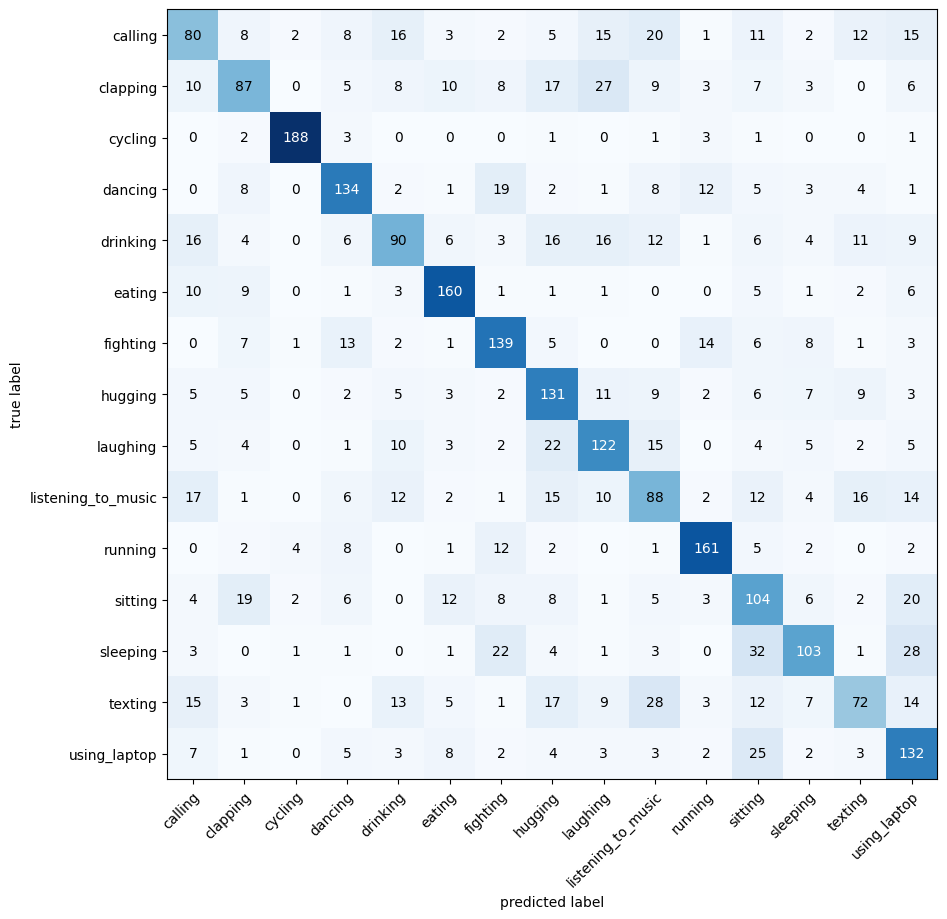

In [ ]:
make_confusion_matrix(model=model_2, test_loader=test_loader)